In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import math
from PIL import Image, ImageOps
from plotnine import (ggplot, aes, geom_map, geom_text, geom_label,
                     ggtitle, element_blank, element_rect,
                     scale_fill_manual, theme_minimal, theme, scale_fill_cmap)
import os
import glob
import re
from scipy.stats import percentileofscore


# Prep Dataframes

In [ ]:
# Get voter data

# Input relevant election year
election_year=2024
voter_file_name = './data/voter_numbers_{}.csv'

votes_df=pd.read_csv(voter_file_name.format(election_year))
# votes_df['indep_votes'] = votes_df['indep_votes'].replace(np.nan, 0).astype(int)
votes_df['total_votes'] =  votes_df[['dem_votes', 'rep_votes']].sum(axis=1)
votes_df

,county_id,NAME10,dem_votes,rep_votes,og_district,alt_district,total_votes
0,0,Adair,1086,2916,3,4,4002
1,1,Adams,576,1517,3,3,2093
2,2,Allamakee,2350,4857,2,2,7207
3,3,Appanoose,1686,4704,3,3,6390
4,4,Audubon,970,2214,4,4,3184
...,...,...,...,...,...,...,...
94,94,Winnebago,1909,3636,4,4,5545
95,95,Winneshiek,5321,6427,2,2,11748
96,96,Woodbury,16145,25969,4,4,42114
97,97,Worth,1508,2715,2,4,4223


In [3]:
# Get enacted map Republican vote share as a list ordered by district
enacted_rep_vote_share_list=[]
for i in range(1,5):
    total_votes=votes_df.loc[votes_df['og_district']==i]['total_votes'].sum()
    total_rep_votes=votes_df.loc[votes_df['og_district']==i]['rep_votes'].sum()
    rep_vote_share=total_rep_votes/total_votes
    enacted_rep_vote_share_list.append(rep_vote_share)

# Get alternate map Republican vote share as a list ordered by district\
alternate_rep_vote_share_list=[]
for i in range(1,5):
    total_votes=votes_df.loc[votes_df['alt_district']==i]['total_votes'].sum()
    total_rep_votes=votes_df.loc[votes_df['alt_district']==i]['rep_votes'].sum()
    rep_vote_share=total_rep_votes/total_votes
    alternate_rep_vote_share_list.append(rep_vote_share)

# Functions

## Seat Share

In [4]:
def winner_tabulation(votes_df, realloc_df):
    votes_df['simulation_district']=realloc_df['DISTRICT']
    winners_df=pd.DataFrame(columns=['district', 'dem_votes', 'rep_votes', 'party_winner'])
    for i in range(1,5):
        winners_df.loc[i]=[i,
                      votes_df.loc[votes_df['simulation_district']==i]['dem_votes'].sum(),
                      votes_df.loc[votes_df['simulation_district']==i]['rep_votes'].sum(),
                    # votes_df.loc[votes_df['simulation_district']==i]['indep_votes'].sum(),
                      '']
    for i in range(1,5):
        if votes_df.loc[votes_df['simulation_district']==i]['dem_votes'].sum()>votes_df.loc[votes_df['simulation_district']==i]['rep_votes'].sum():
            winners_df.loc[winners_df['district']==i,'party_winner']='D'
        else:
            winners_df.loc[winners_df['district']==i,'party_winner']='R'
    return winners_df

## Vote share

In [5]:
#returns Republican percentage vote share in each district as a list in ascending order
def rep_vote_share_as_list(votes_df, realloc_df):
    votes_df['simulation_district']=realloc_df['DISTRICT']
    rep_vote_share_list=[]
    for i in range(1,5):
        total_votes=votes_df.loc[votes_df['simulation_district']==i]['total_votes'].sum()
        total_rep_votes=votes_df.loc[votes_df['simulation_district']==i]['rep_votes'].sum()
        rep_vote_share=total_rep_votes/total_votes
        rep_vote_share_list.append(rep_vote_share)
    return sorted(rep_vote_share_list)

## Efficiency Gap

In [6]:
# first argument is the voter number dataframe, second argument is the simulation dataframe with new district assignments
# output is total democrat and republican votes in each district, along with the winning number based on votes cast in district
def district_totals(votes_df, realloc_df):
    votes_df['simulation_district']=realloc_df['DISTRICT']
    district_votes=pd.DataFrame(columns=['district', 'dem_votes', 'rep_votes', 'votes_to_win'])
    for i in range(1,5):
        district_total= votes_df.loc[votes_df['simulation_district']==i]['total_votes'].sum()
        votes_to_win = 0
        if district_total % 2 ==0:
            votes_to_win = votes_to_win+(district_total/2) + 1
        else:
            votes_to_win = votes_to_win+math.ceil(district_total/2)
        district_votes.loc[i]=[i,
                      votes_df.loc[votes_df['simulation_district']==i]['dem_votes'].sum()
                      , votes_df.loc[votes_df['simulation_district']==i]['rep_votes'].sum()
                      , votes_to_win]
    return district_votes 

# input is datadrame with votes by party breakdown in each district with votes needed to win the district
# output is the wasted votes for democrats and republicans

def wasted_votes(district_votes):
    dem_wasted=0
    rep_wasted=0
    for i in range(4):
        if district_votes.iloc[i]['dem_votes']>district_votes.iloc[i]['rep_votes']:
            dem_wasted+= district_votes.iloc[i]['dem_votes']-district_votes.iloc[i]['votes_to_win']
            rep_wasted+=district_votes.iloc[i]['rep_votes']
        else:
            dem_wasted+= district_votes.iloc[i]['dem_votes']
            rep_wasted+=district_votes.iloc[i]['rep_votes']-district_votes.iloc[i]['votes_to_win']
    return dem_wasted, rep_wasted

# compute EG for a given district map. Inputs are the union of district_totals and wasted_votes functions
# output is the efficiency gap as a percentage, rounded to 1 decimal place
def EG_func(votes_df, realloc_df):
    district_votes=district_totals(votes_df, realloc_df)
    total_votes = votes_df['total_votes'].sum()
    all_wasted_votes=wasted_votes(district_votes)
    efficiency_gap = round(((all_wasted_votes[0]-all_wasted_votes[1])/total_votes)*100,2)
    return efficiency_gap

## Mean-Median Difference

In [7]:
# compute Republican mean median difference for district map
# Arguments are election dataframe and dataframe with district assignments
# Output is the mean-median difference as a percent, rounded to two decimal places
def mean_med_diff(votes_df, realloc_df):
    rep_vote_share = rep_vote_share_as_list(votes_df, realloc_df)
    median = (rep_vote_share[1]+rep_vote_share[2])/2
    mean = sum(rep_vote_share)/len(rep_vote_share)
    mean_med_diff = round((mean - median)*100, 2)
    return mean_med_diff

# Analysis 

In [8]:
# This is obsolete, as some of the files in allocation_by_district are for duplicate maps

# #print all csv files from the allocation_by_district folder
# #note: not in order!
# seeds_by_district_csv_files=glob.glob('./allocation_by_county/*.csv')

# #this will get an unsorted list of seeds for all files in ./allocation_by_district folder
# district_seeds_list=[]
# for fname in seeds_by_district_csv_files:
#     res = re.findall("seed_(\d+)_by_county.csv", fname)
#     if not res: continue
#     district_seeds_list.append(res[0]) # You can append the result to a list

# district_seeds_list_sorted=sorted(district_seeds_list)

# Import list of seeds of unique districts (generated by simulation_map_analysis)
dist_seeds_df=pd.read_csv('./data/unique_district_seeds.csv')
district_seeds_list = dist_seeds_df['seed'].tolist()

# # This variable is used for rep_vote_share_df and seat_share_df
file_name = './allocation_by_county/seed_{}_by_county.csv'

## Percent vote share

In [9]:
# Create dataframe with Republican percent vote share in each district
# Column headers 1-4 refer to ascending order of vote share, not district number
rep_percent_vote_share_df=pd.DataFrame(columns=['1', '2', '3', '4'])
for seed in district_seeds_list:
    iter_number=str(seed).rjust(3,'0')
    realloc_df=pd.read_csv(file_name.format(iter_number))
    votes_df['simulation_district']=realloc_df['DISTRICT']
    rep_percent_vote_share_df.loc[len(rep_percent_vote_share_df)]=rep_vote_share_as_list(votes_df, realloc_df)

In [10]:
#unstack dataframe to prep for graphics
simulation_df=rep_percent_vote_share_df.unstack().reset_index(drop=False)
simulation_df=simulation_df.drop(columns=['level_1'])
simulation_df=simulation_df.rename(columns={"level_0": "rank_order", 0:"percentage"})
simulation_df

,rank_order,percentage
0,1,0.510298
1,1,0.526170
2,1,0.486833
3,1,0.510557
4,1,0.519687
...,...,...
855,4,0.666152
856,4,0.646324
857,4,0.686668
858,4,0.665764


In [11]:
# Create vote share for enacted (Proposal 2) and alternate (Proposal 1) 2021 maps for scatterplot and boxplot overlay
list=sorted(enacted_rep_vote_share_list)
enacted_dict={'rank_order':[0,1,2,3], 'percentage': list}
enacted_map_df=pd.DataFrame(enacted_dict)

list2=sorted(alternate_rep_vote_share_list)
alternate_dict = {'rank_order':[0,1,2,3], 'percentage': list2}
alternate_map_df=pd.DataFrame(alternate_dict)

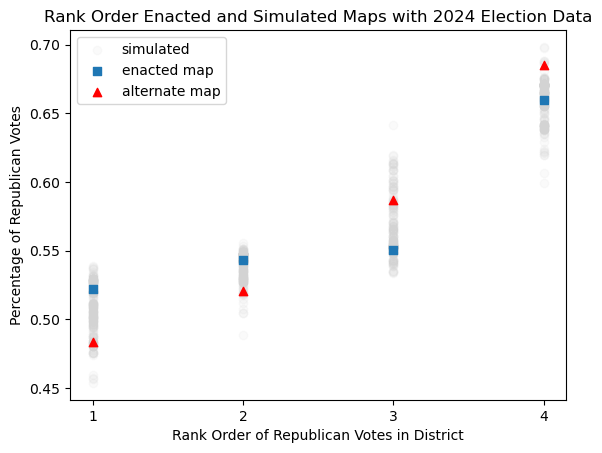

In [12]:
X=simulation_df['rank_order']
Y=simulation_df['percentage']
x=enacted_map_df['rank_order']
y=enacted_map_df['percentage']
a=alternate_map_df['rank_order']
b=alternate_map_df['percentage']

plt.scatter(X, Y, alpha=.1, color='lightgray', zorder=1, label='simulated')
plt.scatter(x, y, zorder=2, marker=',', label='enacted map')
plt.scatter(a, b, zorder=3, marker='^', color='red', label='alternate map')
plt.xlabel('Rank Order of Republican Votes in District')
plt.ylabel('Percentage of Republican Votes')
plt.title('Rank Order Enacted and Simulated Maps with {} Election Data'.format(election_year))
plt.legend(loc='upper left')
plt.savefig('./images_for_paper/rank_order_scatterplot_{}.png'.format(election_year))
plt.show()

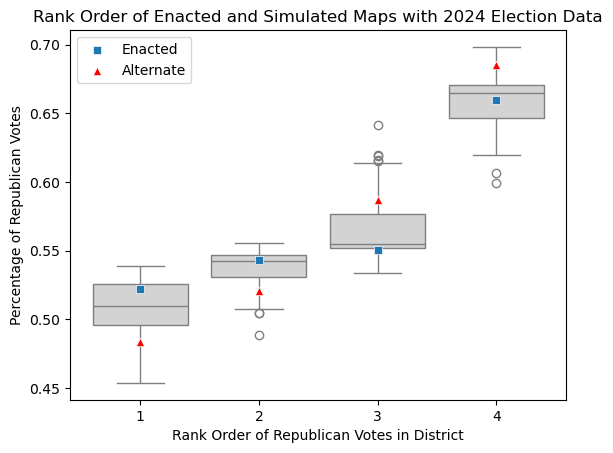

In [13]:
sns.boxplot(x=X, y=Y,color='lightgray', zorder=1)
sns.scatterplot(x=x, y=y,zorder=2, marker=',', label='Enacted')
sns.scatterplot(x=a, y=b, zorder=3, marker='^', color='red', label='Alternate')
plt.xlabel('Rank Order of Republican Votes in District')
plt.ylabel('Percentage of Republican Votes')
plt.title('Rank Order of Enacted and Simulated Maps with {} Election Data'.format(election_year))
plt.savefig('./images_for_paper/rank_order_boxplot_{}.png'.format(election_year))
plt.legend(loc='upper left')

## Seat share, efficiency gap, mean-median difference

In [ ]:
winners_list=[]
for seed in district_seeds_list:
    # realloc_df=pd.read_csv(file)
    iter_number=str(seed).rjust(3,'0')
    realloc_df=pd.read_csv(file_name.format(iter_number))
    votes_df['simulation_district']=realloc_df['DISTRICT']
    winners=winner_tabulation(votes_df, realloc_df)
    dems=winners.loc[winners['party_winner']=='D'].shape[0]
    reps=winners.loc[winners['party_winner']=='R'].shape[0]
    efficiency_gap=EG_func(votes_df, realloc_df)
    mean_med = mean_med_diff(votes_df, realloc_df)
    winners_list.append([seed, dems, reps, efficiency_gap, mean_med])

In [ ]:
seat_share_df=pd.DataFrame(winners_list,columns=['iteration', 'dem_seats', 'rep_seats', 'efficiency_gap', 'mean_median_difference'])
seat_share_df

In [ ]:
seat_share_df[seat_share_df['iteration']==208]

In [ ]:
seat_share_df.to_csv("data/seat_share_{}.csv".format(election_year), index=False, header=True)

In [ ]:
seats = seat_share_df['rep_seats']
plt.hist(seats,bins=np.arange(0,6)+0.5, ec="k")
plt.xlabel('Number of Republican Seats')
plt.ylabel('Number of Districts')
plt.title('Republican Seat Share in Simulated Maps with {} Election Data'.format(election_year))
plt.savefig('./images_for_paper/republican_seat_share_{}.png'.format(election_year))


In [ ]:
#Percentage of simulated maps with at least 1 democratic winner based on 2022 voter numbers
len(seat_share_df.loc[seat_share_df['dem_seats']>0])/215

In [ ]:
plt.scatter(seat_share_df['efficiency_gap'], seat_share_df['rep_seats'], color='lightgray',  alpha=.2, zorder=1, label='simulated')
plt.scatter(x=37, y=[4], zorder=2, marker=',', label='enacted map')
# plt.scatter(a, b, zorder=3, label='alternate map')
plt.xlabel('Efficiency Gap')
plt.ylabel('Number of Republican Seats')
plt.title('Efficiency Gaps for Enacted and Simulated Maps with {} Election Data'.format(election_year))
plt.legend(loc='upper left')
plt.savefig('./images_for_paper/efficiency_gap_{}.png'.format(election_year))
plt.show()

In [ ]:
seat_share_df['efficiency_gap'].describe()

In [ ]:
# boxplot separated by Republican seat share
# Need to label axes and add title
sns.swarmplot(x=seat_share_df['efficiency_gap'], hue=seat_share_df['rep_seats'])

In [ ]:
alt_map_mm = round((alternate_map_df['percentage'].mean()-alternate_map_df['percentage'].median())*100, 2)
alt_map_mm

In [ ]:
percentileofscore(seat_share_df['mean_median_difference'], alt_map_mm)

In [ ]:
enacted_map_mm = round((enacted_map_df['percentage'].mean()-enacted_map_df['percentage'].median())*100, 2)
enacted_map_mm

In [ ]:
percentileofscore(seat_share_df['mean_median_difference'], enacted_map_mm)

In [ ]:
seat_share_df['mean_median_difference'].describe()

In [ ]:
seat_share_df.loc[seat_share_df['iteration']=='208']

In [ ]:
seat_share_df.head()

In [ ]:
rep_percent_vote_share_df

In [ ]:
MM_diff=seat_share_df['mean_median_difference']
reps=seat_share_df['rep_seats']
sns.boxplot(x=reps, y=MM_diff, color='lightgray', zorder=1)
sns.scatterplot(x=[2], y=enacted_map_mm,zorder=2,marker=',', label='Enacted')
sns.scatterplot(x=[1], y=alt_map_mm, marker='^', color='red',zorder=3, label='Alternate')
plt.xlabel('Number of Republican Seats in District')
plt.ylabel('Mean-Median Difference for Republican Vote Share')
plt.title('Mean-Median Difference vs. Republican Seat Share with {} Election Data'.format(election_year))
plt.savefig('./images_for_paper/mean_median_vs_seats_{}.png'.format(election_year))

# plt.legend(loc='upper left')

In [ ]:
sns.boxplot(MM_diff, color='lightgray', zorder=1)
sns.scatterplot(x=[0], y=enacted_map_mm,zorder=2,marker=',', label='Enacted')
sns.scatterplot(x=[0], y=alt_map_mm, marker='^', color='red',zorder=3, label='Alternate')
plt.ylabel('Mean-Median Difference for Republican Vote Share')
plt.title('Mean-Median Difference of Republican Vote Share with {} Election Data'.format(election_year))
plt.savefig('./images_for_paper/mean_median_{}.png'.format(election_year))
